<a href="https://colab.research.google.com/github/Anuska111/SCFP2019-/blob/main/SCFP2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("/content/SCFP2019 (2).csv")

In [ ]:
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5,3,6,3,2,10,6,6,3,3
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5,2,6,2,1,10,4,4,2,2
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5,3,6,3,1,10,5,5,2,2


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled) # Assumes X_scaled is available from a previous cell
print("KMeans Model Definition and Attributes:")
print(f"Number of clusters: {kmeans.n_clusters}")
print("Cluster centers:\n", kmeans.cluster_centers_)
print(f"Model inertia: {kmeans.inertia_}")

KMeans Model Definition and Attributes:


NameError: name 'kmeans' is not defined

In [ ]:
age_groups=df_fear["AGECL"].unique()
print("Age Groups:",age_groups)

Age Groups: [3 5 1 2 4 6]


In [ ]:
agecl_dict={
    1:"Under 35",
    2:"35-44",
    3:"45-54",
    4:"55-64",
    5:"65-74",
    6:"75 or Older"
}
age_cl=df_fear["AGECL"].replace(agecl_dict)
age_cl.head(10)

,AGECL
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54
110,65-74
111,65-74
112,65-74
113,65-74
114,65-74


<Axes: xlabel='AGECL'>

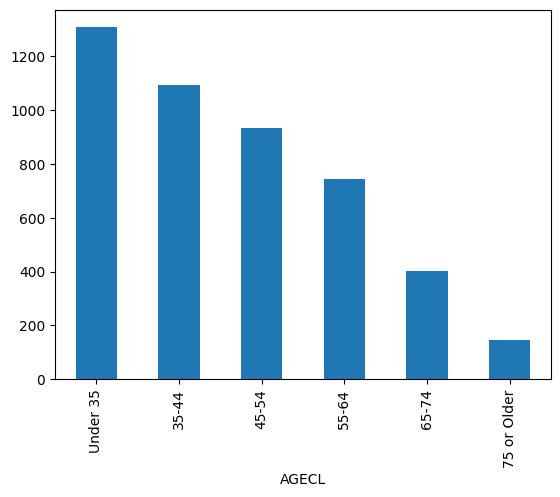

In [ ]:
age_cl_value_counts=age_cl.value_counts()
age_cl_value_counts.plot(kind='bar')

<Axes: >

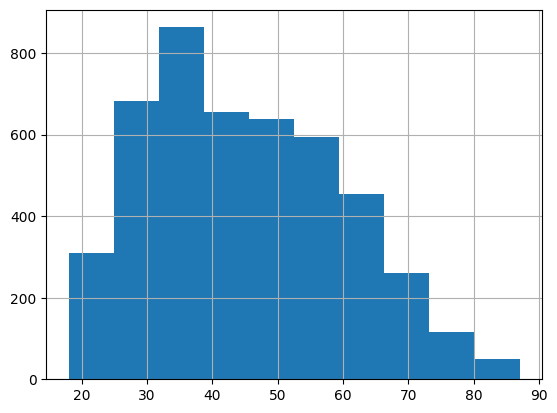

In [ ]:
df_fear["AGE"].hist(bins=10)

In [ ]:
inccat_dict={
    1:"0-20",
    2:"20-39.9",
    3:"40-59.9",
    4:"60-79.9",
    5:"80-89.9",
    6:"90-100"
}
inccat=df_fear["INCCAT"].replace(inccat_dict)
inccat.head(10)

,INCCAT
5,20-39.9
6,20-39.9
7,20-39.9
8,20-39.9
9,20-39.9
110,0-20
111,0-20
112,0-20
113,0-20
114,0-20


<Axes: xlabel='INCCAT'>

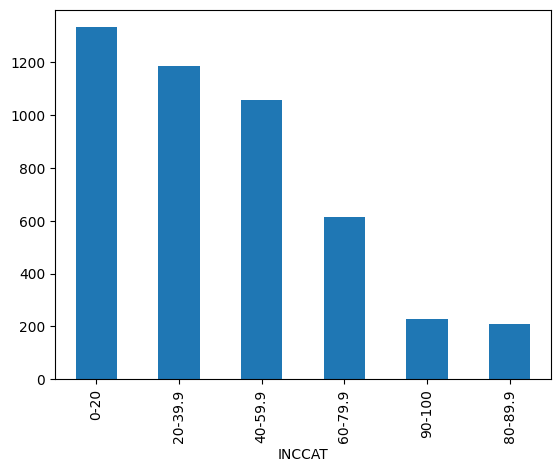

In [ ]:
inccat_val_counts=inccat.value_counts()
inccat_val_counts.plot(kind='bar')

In [ ]:
columns=["ASSET","HOUSES","INCOME","DEBT","EDUC"]
corr=df[columns].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.519827,0.622429,0.261250,0.116673
HOUSES,0.519827,1.000000,0.247852,0.266661,0.169300
INCOME,0.622429,0.247852,1.000000,0.114646,0.069400
DEBT,0.261250,0.266661,0.114646,1.000000,0.054179
EDUC,0.116673,0.169300,0.069400,0.054179,1.000000


In [ ]:
corr_fear=df_fear[columns].corr()
corr_fear.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


<Figure size 1200x600 with 0 Axes>

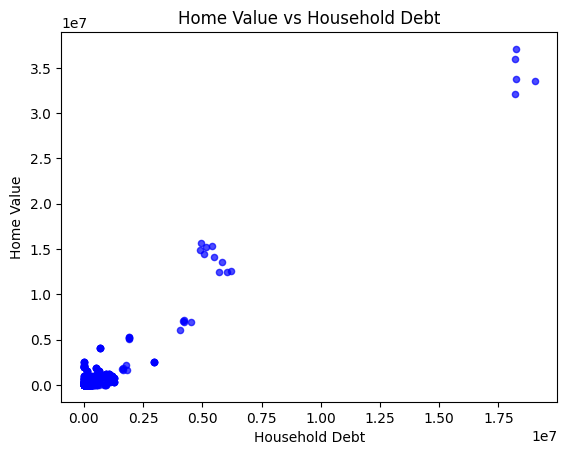

In [ ]:
plt.figure(figsize=(12,6))
df_fear.plot.scatter(x='DEBT',y="HOUSES",c='blue',alpha=0.7,marker='o')
plt.xlabel('Household Debt')
plt.ylabel('Home Value')
plt.title('Home Value vs Household Debt')
plt.show()

In [ ]:
df["TURNFEAR"].value_counts()

,count
TURNFEAR,
0,24262
1,4623


In [ ]:
features=["AGE","INCCAT","NWCAT","ASSETCAT"]
X=df[features]
X=X.dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

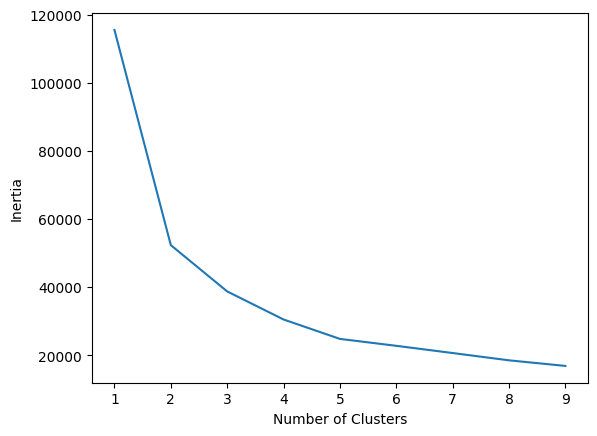

In [ ]:
inertia=[]
for k in range (1,10):
   model=KMeans(n_clusters=k,random_state=42)
   model.fit(X_scaled)
   inertia.append(model.inertia_)

plt.plot(range(1,10),inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X_scaled)

clusters=kmeans.labels_
X["Clusters"]=clusters
X.groupby("Clusters").mean()

,AGE,INCCAT,NWCAT,ASSETCAT
Clusters,,,,
0,59.049449,5.367666,4.606200,5.567000
1,36.359261,2.621108,1.642111,1.996412
2,65.100766,2.319829,2.509934,2.832489


In [ ]:
labels = kmeans.labels_
labels[:10]

NameError: name 'model' is not defined

In [ ]:
sns.scatterplot(
    x=df["DEBT"]/1e6,
    y=df["HOUSES"]/1e6,
    hue=labels,
    palette="deep"
)
plt.xlabel("Household Debt($1M)")
plt.ylabel("Home Value($1M)")
plt.title("Home Value vs Household Debt")
plt.show()

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1450220719.py, line 2)